# General Test Model

Import the Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

Load Data

In [2]:
df = pd.read_csv('Mental disorder symptoms.csv')

Learn more about the Data

In [3]:
df

,ag+1:629e,feeling.nervous,panic,breathing.rapidly,sweating,trouble.in.concentration,having.trouble.in.sleeping,having.trouble.with.work,hopelessness,anger,...,having.nightmares,avoids.people.or.activities,feeling.negative,trouble.concentrating,blamming.yourself,hallucinations,repetitive.behaviour,seasonally,increased.energy,Disorder
0,23,1,0,1,0,0,1,0,1,0,...,0,0,1,0,0,0,0,0,0,Major Depressive Disorder (MDD)
1,14,1,0,1,0,0,1,0,0,1,...,1,1,0,0,0,0,1,0,0,Autism Spectrum Disorder (ASD)
2,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Loneliness
3,29,1,0,0,0,1,1,0,0,0,...,0,0,0,1,1,0,0,0,1,Bipolar
4,32,1,1,1,1,1,1,1,0,0,...,0,1,0,0,0,0,0,0,0,Anxiety
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632,23,1,0,1,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Eating Disorder
633,27,1,0,1,0,0,0,0,1,1,...,1,0,1,1,1,0,0,0,0,Persistent Depressive Disorder (PDD)
634,19,0,1,0,0,1,0,1,0,0,...,0,1,0,1,0,0,1,0,1,Autism Spectrum Disorder (ASD)
635,16,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,Loneliness


In [4]:
df.head()

,ag+1:629e,feeling.nervous,panic,breathing.rapidly,sweating,trouble.in.concentration,having.trouble.in.sleeping,having.trouble.with.work,hopelessness,anger,...,having.nightmares,avoids.people.or.activities,feeling.negative,trouble.concentrating,blamming.yourself,hallucinations,repetitive.behaviour,seasonally,increased.energy,Disorder
0,23,1,0,1,0,0,1,0,1,0,...,0,0,1,0,0,0,0,0,0,Major Depressive Disorder (MDD)
1,14,1,0,1,0,0,1,0,0,1,...,1,1,0,0,0,0,1,0,0,Autism Spectrum Disorder (ASD)
2,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Loneliness
3,29,1,0,0,0,1,1,0,0,0,...,0,0,0,1,1,0,0,0,1,Bipolar
4,32,1,1,1,1,1,1,1,0,0,...,0,1,0,0,0,0,0,0,0,Anxiety


In [5]:
print(f"The shape of the Data is {df.shape}")
df.describe()

The shape of the Data is (637, 29)


,ag+1:629e,feeling.nervous,panic,breathing.rapidly,sweating,trouble.in.concentration,having.trouble.in.sleeping,having.trouble.with.work,hopelessness,anger,...,popping.up.stressful.memory,having.nightmares,avoids.people.or.activities,feeling.negative,trouble.concentrating,blamming.yourself,hallucinations,repetitive.behaviour,seasonally,increased.energy
count,637.000000,637.000000,637.000000,637.000000,637.000000,637.000000,637.000000,637.000000,637.000000,637.000000,...,637.000000,637.000000,637.000000,637.000000,637.000000,637.000000,637.000000,637.000000,637.0,637.000000
mean,22.189953,0.638932,0.273155,0.549451,0.368917,0.365777,0.638932,0.273155,0.232339,0.324961,...,0.459969,0.329670,0.364207,0.340659,0.408163,0.244898,0.102041,0.288854,0.0,0.230769
std,8.395680,0.480688,0.445930,0.497940,0.482891,0.482026,0.480688,0.445930,0.422656,0.468728,...,0.498787,0.470463,0.481585,0.474303,0.491880,0.430365,0.302940,0.453586,0.0,0.421656
min,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
50%,21.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
75%,28.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.0,0.000000
max,46.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000


In [6]:
df.isnull().sum()

,0
ag+1:629e,0
feeling.nervous,0
panic,0
breathing.rapidly,0
sweating,0
trouble.in.concentration,0
having.trouble.in.sleeping,0
having.trouble.with.work,0
hopelessness,0
anger,0


In [7]:
df.duplicated().sum()

np.int64(523)

In [8]:
'''
There are duplicates but when deleting it it'll shrink the shape of the data
from (637, 29) into (114, 29)
'''
df.drop_duplicates(inplace=True)
print(f"The shape of the Data is {df.shape}")

The shape of the Data is (114, 29)


In [9]:
df.describe()

,ag+1:629e,feeling.nervous,panic,breathing.rapidly,sweating,trouble.in.concentration,having.trouble.in.sleeping,having.trouble.with.work,hopelessness,anger,...,popping.up.stressful.memory,having.nightmares,avoids.people.or.activities,feeling.negative,trouble.concentrating,blamming.yourself,hallucinations,repetitive.behaviour,seasonally,increased.energy
count,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,...,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.0,114.000000
mean,22.745614,0.596491,0.245614,0.500000,0.333333,0.403509,0.649123,0.280702,0.219298,0.280702,...,0.464912,0.289474,0.333333,0.324561,0.456140,0.219298,0.131579,0.298246,0.0,0.271930
std,8.706433,0.492767,0.432351,0.502208,0.473486,0.492767,0.479352,0.451326,0.415598,0.451326,...,0.500969,0.455520,0.473486,0.470278,0.500272,0.415598,0.339525,0.459508,0.0,0.446918
min,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
50%,21.000000,1.000000,0.000000,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
75%,28.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.0,1.000000
max,46.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000


Text(0.5, 1.0, 'Disorder Distribution')

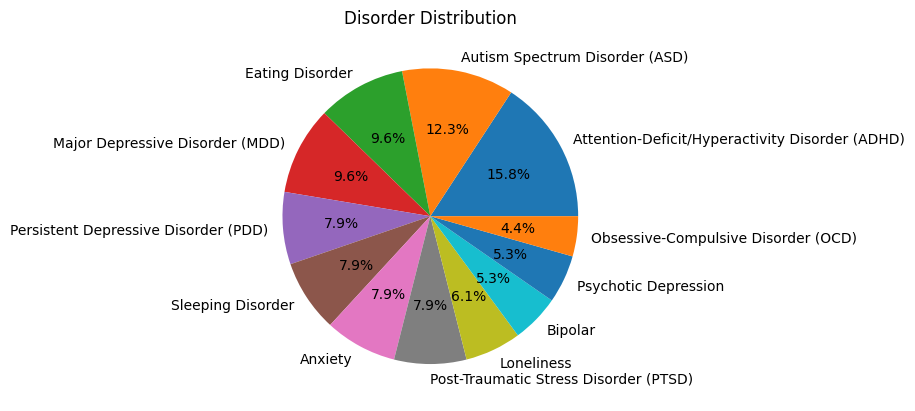

In [10]:
Disorder_counts = df['Disorder'].value_counts()

plt.pie(Disorder_counts, labels=Disorder_counts.index, autopct='%1.1f%%')
plt.title('Disorder Distribution')

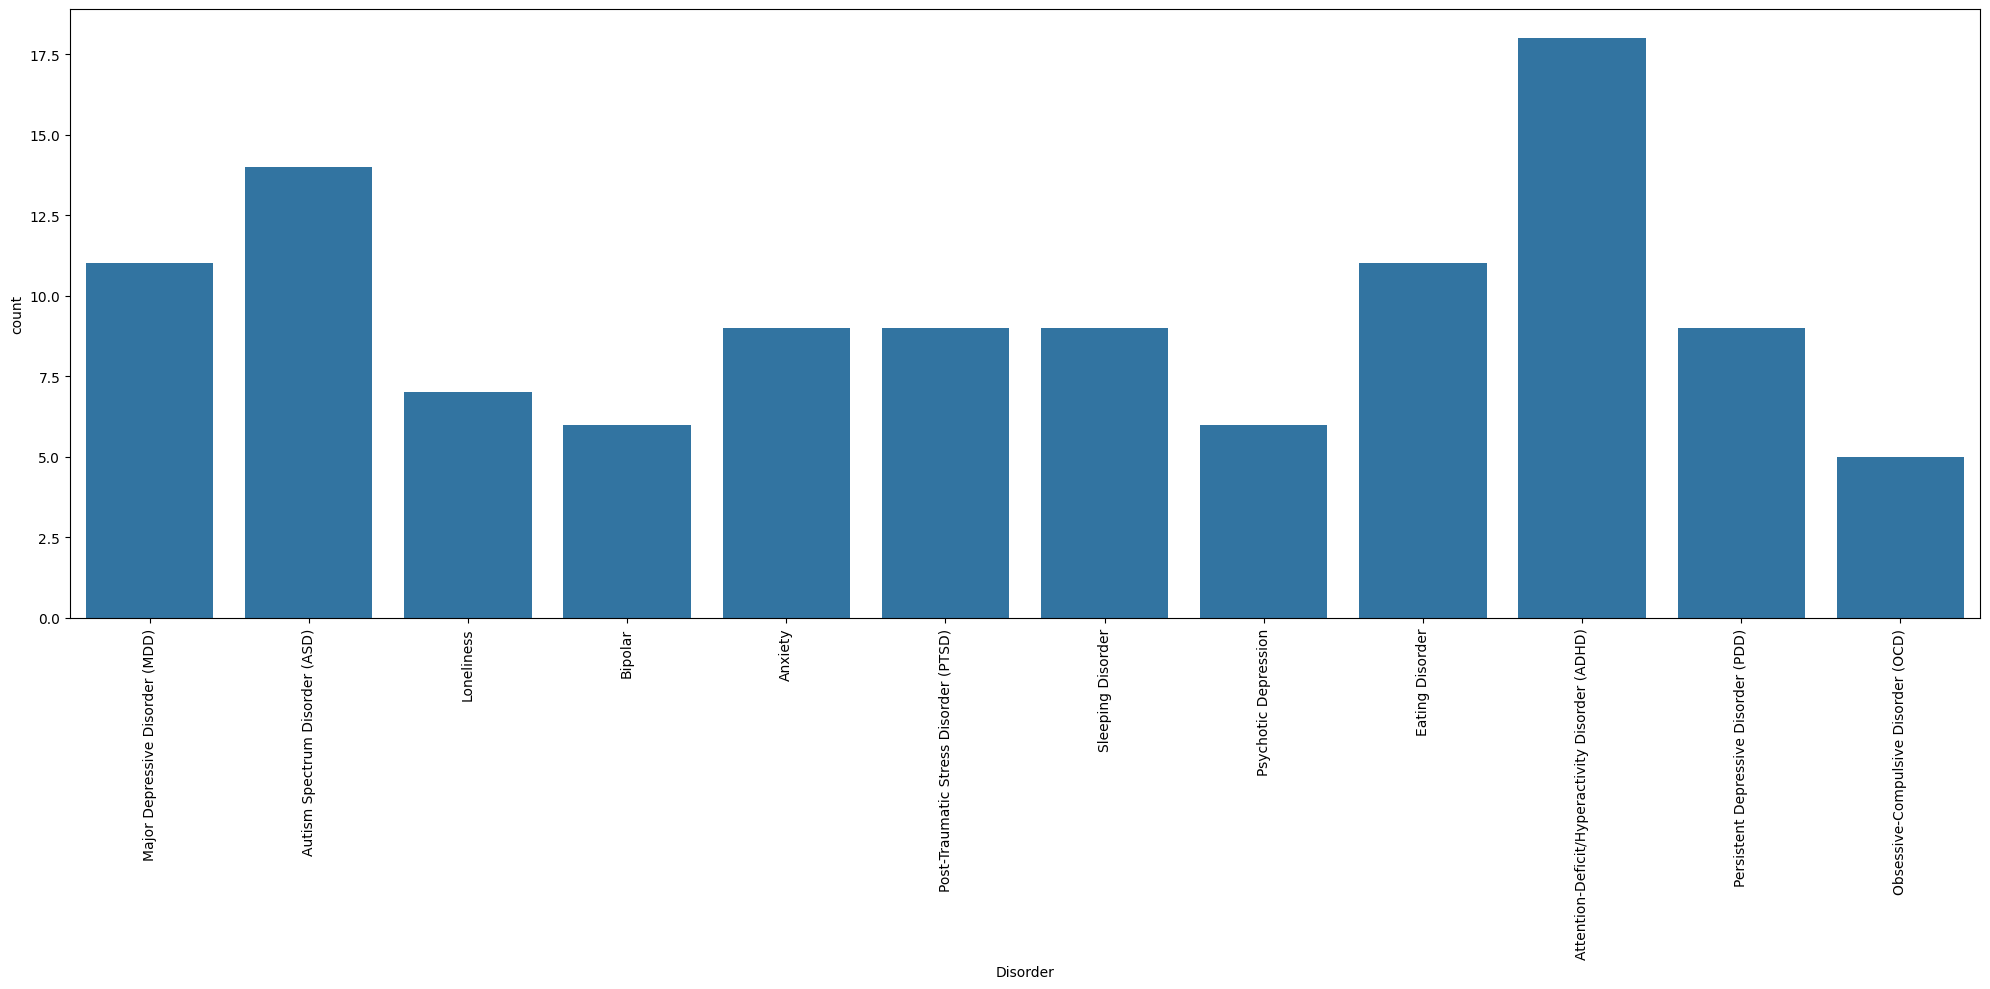

In [11]:
plt.figure(figsize=(20, 10))
sns.countplot(x=df['Disorder'])
plt.xticks(rotation=90)
plt.tight_layout()

In [12]:
le = LabelEncoder()
df['Disorder'] = le.fit_transform(df['Disorder'])

In [13]:
#To make a list of the diagnosis and it's encoded value
mapping = list(zip(le.classes_, range(len(le.classes_))))
print(mapping)

[('Anxiety', 0), ('Attention-Deficit/Hyperactivity Disorder (ADHD)', 1), ('Autism Spectrum Disorder (ASD)', 2), ('Bipolar', 3), ('Eating Disorder', 4), ('Loneliness', 5), ('Major Depressive Disorder (MDD)', 6), ('Obsessive-Compulsive Disorder (OCD)', 7), ('Persistent Depressive Disorder (PDD)', 8), ('Post-Traumatic Stress Disorder (PTSD)', 9), ('Psychotic Depression', 10), ('Sleeping Disorder', 11)]


In [14]:
df.head(10)

,ag+1:629e,feeling.nervous,panic,breathing.rapidly,sweating,trouble.in.concentration,having.trouble.in.sleeping,having.trouble.with.work,hopelessness,anger,...,having.nightmares,avoids.people.or.activities,feeling.negative,trouble.concentrating,blamming.yourself,hallucinations,repetitive.behaviour,seasonally,increased.energy,Disorder
0,23,1,0,1,0,0,1,0,1,0,...,0,0,1,0,0,0,0,0,0,6
1,14,1,0,1,0,0,1,0,0,1,...,1,1,0,0,0,0,1,0,0,2
2,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
3,29,1,0,0,0,1,1,0,0,0,...,0,0,0,1,1,0,0,0,1,3
4,32,1,1,1,1,1,1,1,0,0,...,0,1,0,0,0,0,0,0,0,0
5,40,1,1,1,1,1,1,0,0,1,...,1,0,0,0,1,0,1,0,0,9
6,18,0,0,0,0,0,1,1,0,0,...,0,0,0,1,0,0,0,0,0,11
7,32,1,0,1,0,1,1,1,1,0,...,0,1,1,1,0,1,0,0,0,10
8,24,1,1,1,0,1,0,0,0,0,...,0,1,0,1,0,0,1,0,0,2
9,37,1,0,1,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,4


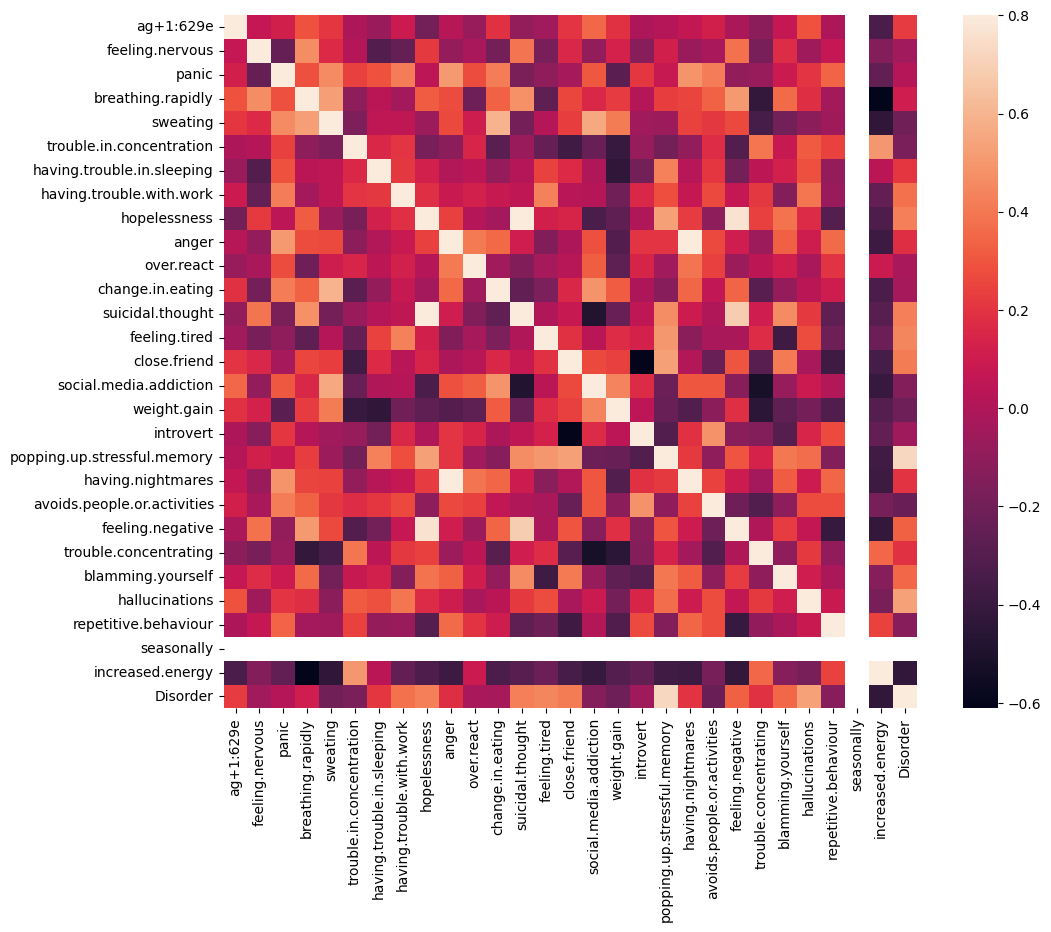

In [15]:
corrmat = df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True);

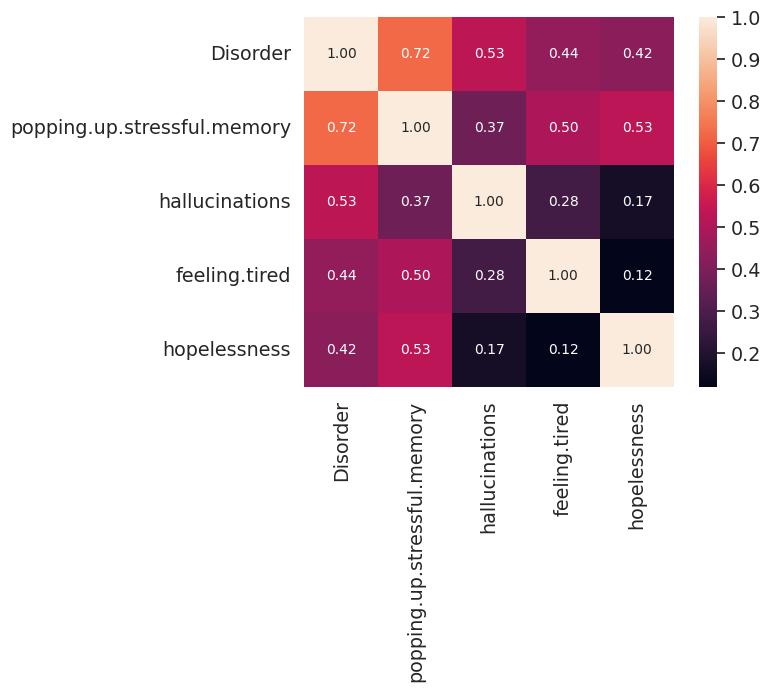

In [16]:
k = 5 #number of variables for heatmap
cols = corrmat.nlargest(k, 'Disorder')['Disorder'].index # nlargest pick the most powerfull 10 correlation
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [17]:
X = df.drop('Disorder', axis=1)
y = df['Disorder']

In [18]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

print(f"the shape of the training set (input) is: {x_train.shape}")
print(f"the shape of the training set (target) is: {y_train.shape}\n")
print(f"the shape of the test set (input) is: {x_test.shape}")
print(f"the shape of the test set (target) is: {y_test.shape}")

the shape of the training set (input) is: (79, 28)
the shape of the training set (target) is: (79,)

the shape of the test set (input) is: (35, 28)
the shape of the test set (target) is: (35,)


In [19]:
rf_classifier = RandomForestClassifier(n_estimators=10, random_state=42)
rf_classifier.fit(x_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [20]:
pred = rf_classifier.predict(x_test)
print("Prediction Results")
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=le.classes_))

Prediction Results
Accuracy: 0.9428571428571428
                                                 precision    recall  f1-score   support

                                        Anxiety       1.00      1.00      1.00         3
Attention-Deficit/Hyperactivity Disorder (ADHD)       1.00      1.00      1.00         6
                 Autism Spectrum Disorder (ASD)       1.00      1.00      1.00         3
                                        Bipolar       1.00      1.00      1.00         2
                                Eating Disorder       1.00      1.00      1.00         3
                                     Loneliness       1.00      1.00      1.00         2
                Major Depressive Disorder (MDD)       0.50      1.00      0.67         2
            Obsessive-Compulsive Disorder (OCD)       1.00      1.00      1.00         2
           Persistent Depressive Disorder (PDD)       1.00      0.60      0.75         5
          Post-Traumatic Stress Disorder (PTSD)       1.00   

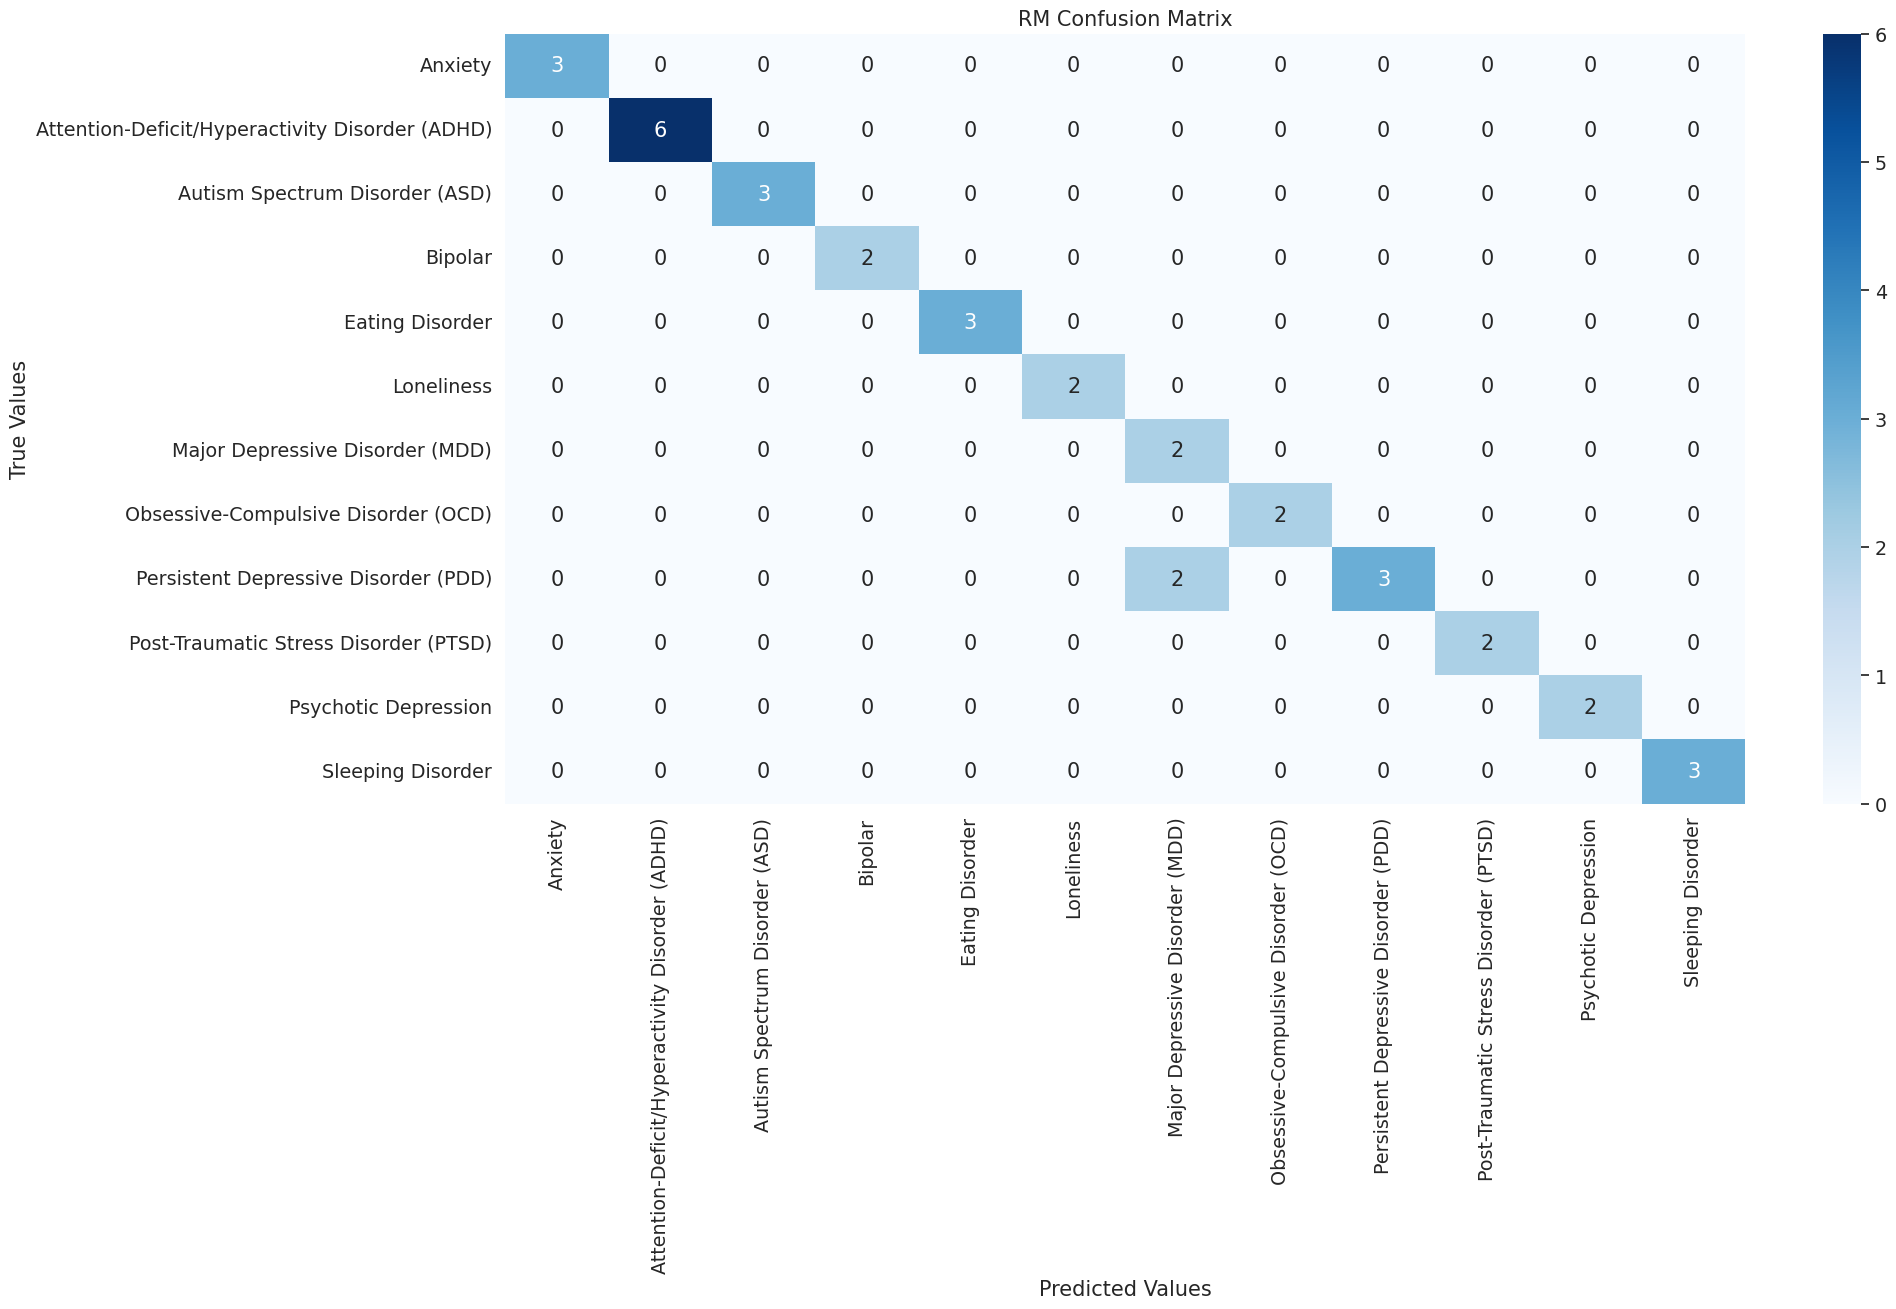

In [21]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(20, 10))
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Values")
plt.ylabel("True Values")
plt.title("RM Confusion Matrix")
plt.show()

In [22]:
"""import joblib

joblib.dump({'model': rf_classifier, 'features': X.columns.tolist()}, 'general_RMmodel.joblib')

from google.colab import files
files.download('general_RMmodel.joblib')"""

"import joblib\n\njoblib.dump({'model': rf_classifier, 'features': X.columns.tolist()}, 'general_RMmodel.joblib')\n\nfrom google.colab import files\nfiles.download('general_RMmodel.joblib')"

In [23]:
"""import joblib
joblib.dump(rf_classifier, "general_RMmodel.pkl")
from google.colab import files
files.download('general_RMmodel.pkl')"""

'import joblib\njoblib.dump(rf_classifier, "general_RMmodel.pkl")\nfrom google.colab import files\nfiles.download(\'general_RMmodel.pkl\')'

In [24]:
n_estimators_range = np.arange(10, 501, 50)
print(f"Defined n_estimators_range: {n_estimators_range}")

Defined n_estimators_range: [ 10  60 110 160 210 260 310 360 410 460]


In [25]:
accuracy_scores = []

for n_estimators in n_estimators_range:
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=42
    )
    rf_model.fit(x_train, y_train)
    y_pred = rf_model.predict(x_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

print("Accuracy scores for different n_estimators:", accuracy_scores)

Accuracy scores for different n_estimators: [0.9428571428571428, 0.9428571428571428, 0.9428571428571428, 0.9428571428571428, 0.9428571428571428, 0.9428571428571428, 0.9428571428571428, 0.9428571428571428, 0.9428571428571428, 0.9428571428571428]


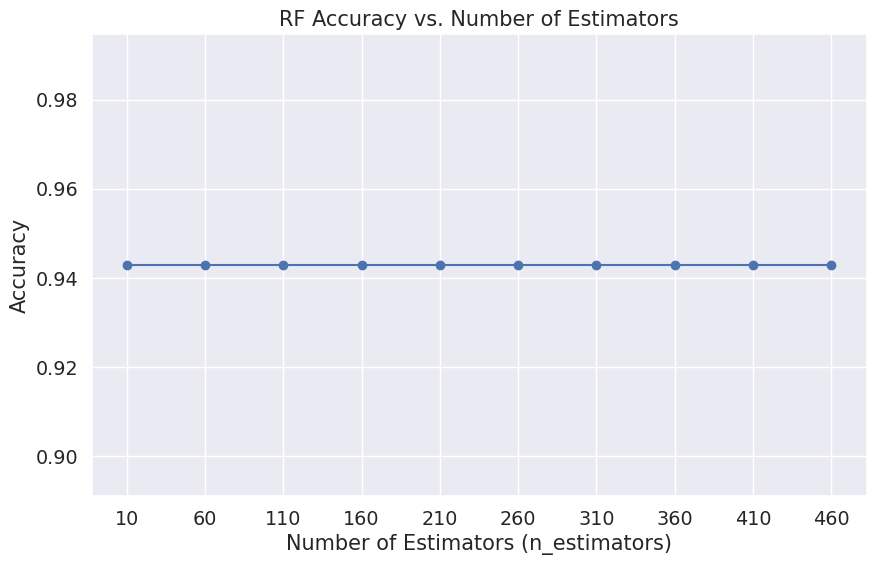

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, accuracy_scores, marker='o')
plt.title('RF Accuracy vs. Number of Estimators')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xticks(n_estimators_range)
plt.show()